In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib
import geopandas as gpd
import jenkspy
from datetime import datetime, timedelta
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import scipy
import prophet
import warnings
warnings.filterwarnings("ignore")
from matplotlib.font_manager import FontProperties
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from scipy.optimize import curve_fit
import matplotlib.colors as colors
import mapclassify
from libpysal.weights.contiguity import Queen
from libpysal import examples
import geopandas as gpd
from esda.moran import Moran_Local
from splot.esda import lisa_cluster
from scipy.interpolate import UnivariateSpline

In [3]:
font = FontProperties(family='DejaVu Sans', weight='bold')


In [46]:
# data = 'mp'
data = 'mp'

In [47]:
# model = 'rho', 'bcv'
model = 'bcv'

In [54]:
# spatialw = 'Knn', 'Non'
spatialw = 'Non'

In [55]:
# original run
if data == 'mp':
    if model == 'rho':
        df = pd.read_csv('../../../results/explain_bias/holdout/Final_Results_HoldOut_GS5184_P05_' + spatialw + '/01.Feature Importance/Feature_Importance.csv')
    else:
        df = pd.read_csv('../../../results/explain_bias/blocked_cv/Final_Results_BlockedCV_GS5184_P05_' + spatialw + '/01.Feature Importance/Feature_Importance_CV_Avg.csv')
else:
    if model == 'rho':
        df = pd.read_csv('../../../results/explain_bias/holdout/Final_Results_HoldOut_GS5184_TTS_' + spatialw + '/01.Feature Importance/Feature_Importance.csv')
    else:
        df = pd.read_csv('../../../results/explain_bias/blocked_cv/Final_Results_BlockedCV_GS5184_TTS_' + spatialw + '/01.Feature Importance/Feature_Importance_CV_Avg.csv')

df = df.sort_values(by=['Impact_SHAP_Value'])

In [57]:
# sensitivity analysis with no pop or no hh
if data == "mp":
    df = pd.read_csv(
        "../../../results/explain_bias/blocked_cv/sensitivity_no_pop_house/"
        + "Final_Results_BlockedCV_GS5184_P05_"
        + spatialw
        + "/01.Feature Importance/Feature_Importance_CV_Avg.csv"
    )
else:
    df = pd.read_csv(
        "../../../results/explain_bias/blocked_cv/sensitivity_no_pop_house/"
        + "Final_Results_BlockedCV_GS5184_TTS_"
        + spatialw
        + "/01.Feature Importance/Feature_Importance_CV_Avg.csv"
    )

df = df.sort_values(by=["Impact_SHAP_Value"])

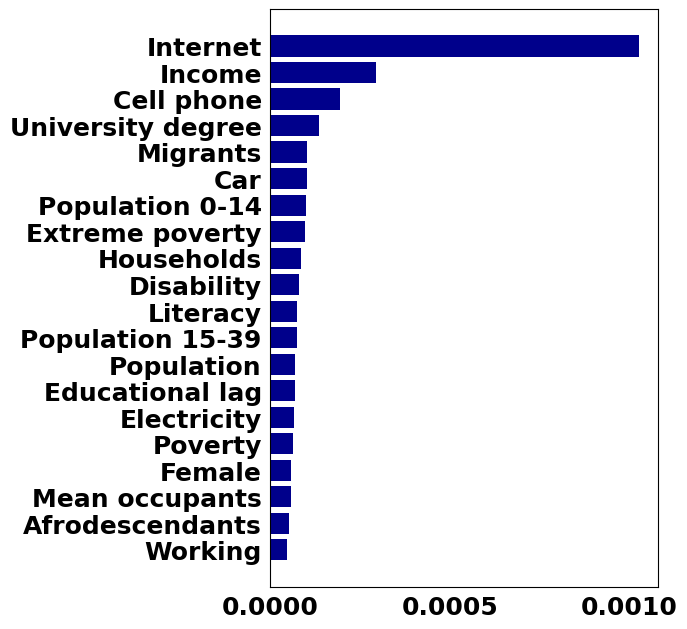

In [56]:
fig, ax = plt.subplots(figsize=(5, 7.5))

if data == 'mp':
    color = 'darkblue'
else:
    color = 'crimson'
    
plt.barh(df['Feature_Label'], df['Impact_SHAP_Value'], color=color)

ax.tick_params(axis='both', which='both', width=0, length=0, labelsize=86, pad=6)

ax.set_xticks([0, 0.0005, 0.0010])

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(font)
    label.set_fontsize(18)


# plt.savefig('../plots/importance/importance_' + model + '_' + data + '_' + spatialw + '.png', bbox_inches='tight')


plt.show()

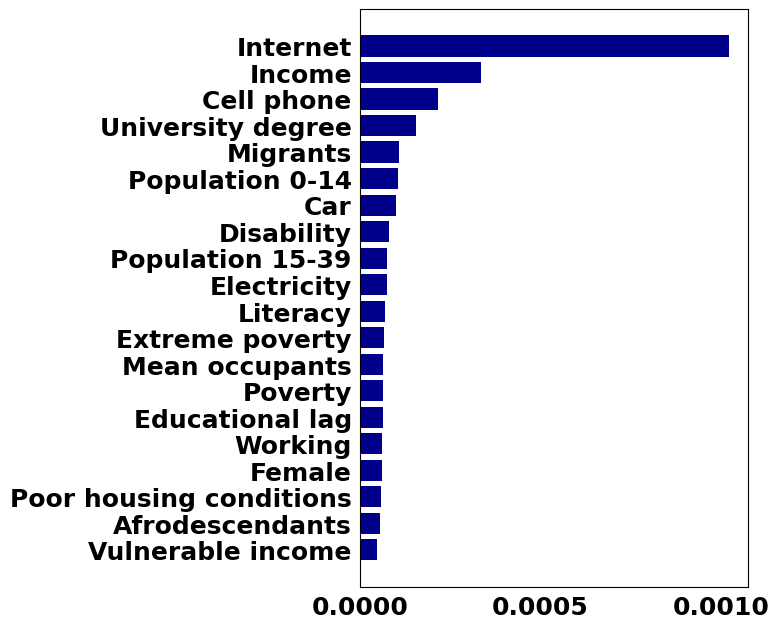

In [58]:
# sensitivity analysis with no pop or no hh
fig, ax = plt.subplots(figsize=(5, 7.5))

if data == "mp":
    color = "darkblue"
else:
    color = "crimson"

plt.barh(df["Feature_Label"], df["Impact_SHAP_Value"], color=color)

ax.tick_params(axis="both", which="both", width=0,
    length=0,
    labelsize=86,
    pad=6
)

ax.set_xticks([0, 0.0005, 0.0010])

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(font)
    label.set_fontsize(18)

plt.savefig("../plots/importance/importance_sensitivity_no_pop_house_" + data + "_" + spatialw + ".png", bbox_inches="tight", dpi=300)

plt.show()